In [91]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

In [92]:
# Load dataset
df = pd.read_excel("project_dataset.xlsx")

In [93]:
# Separate features, target, and country names
X = df.drop(columns=["Country", "BiodiversityIndex"])
y = df["BiodiversityIndex"]
countries = df["Country"]

In [94]:
# Split dataset into training and testing
X_train, X_test, y_train, y_test, countries_train, countries_test = train_test_split(
    X, y, countries, test_size=0.2, random_state=42
)

In [95]:
#scaler = MinMaxScaler()
#scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

In [96]:
# ANN Model

ann_model = MLPRegressor(
    hidden_layer_sizes=(32, 16),      # Smaller layers to avoid overfitting on 157 samples
    activation='relu', 
    solver='adam', 
    alpha=0.1,                      # Moderate regularization
    learning_rate='constant',        # Constant rate is often more stable for pre-scaled data
    learning_rate_init=0.005,
    max_iter=2000,                   
    early_stopping=False,            # Disable early stopping to let it converge fully
    random_state=42
)

# Train the model

ann_model.fit(X_train, y_train)

,loss,'squared_error'
,hidden_layer_sizes,"(32, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.1
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.005
,power_t,0.5
,max_iter,2000
,shuffle,True


In [97]:
# Prediction
y_pred = ann_model.predict(X_test)
y_pred = np.clip(y_pred, 0, 1) 

In [98]:
# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MAE: 0.1031
RMSE: 0.1577
R² Score: 0.5332


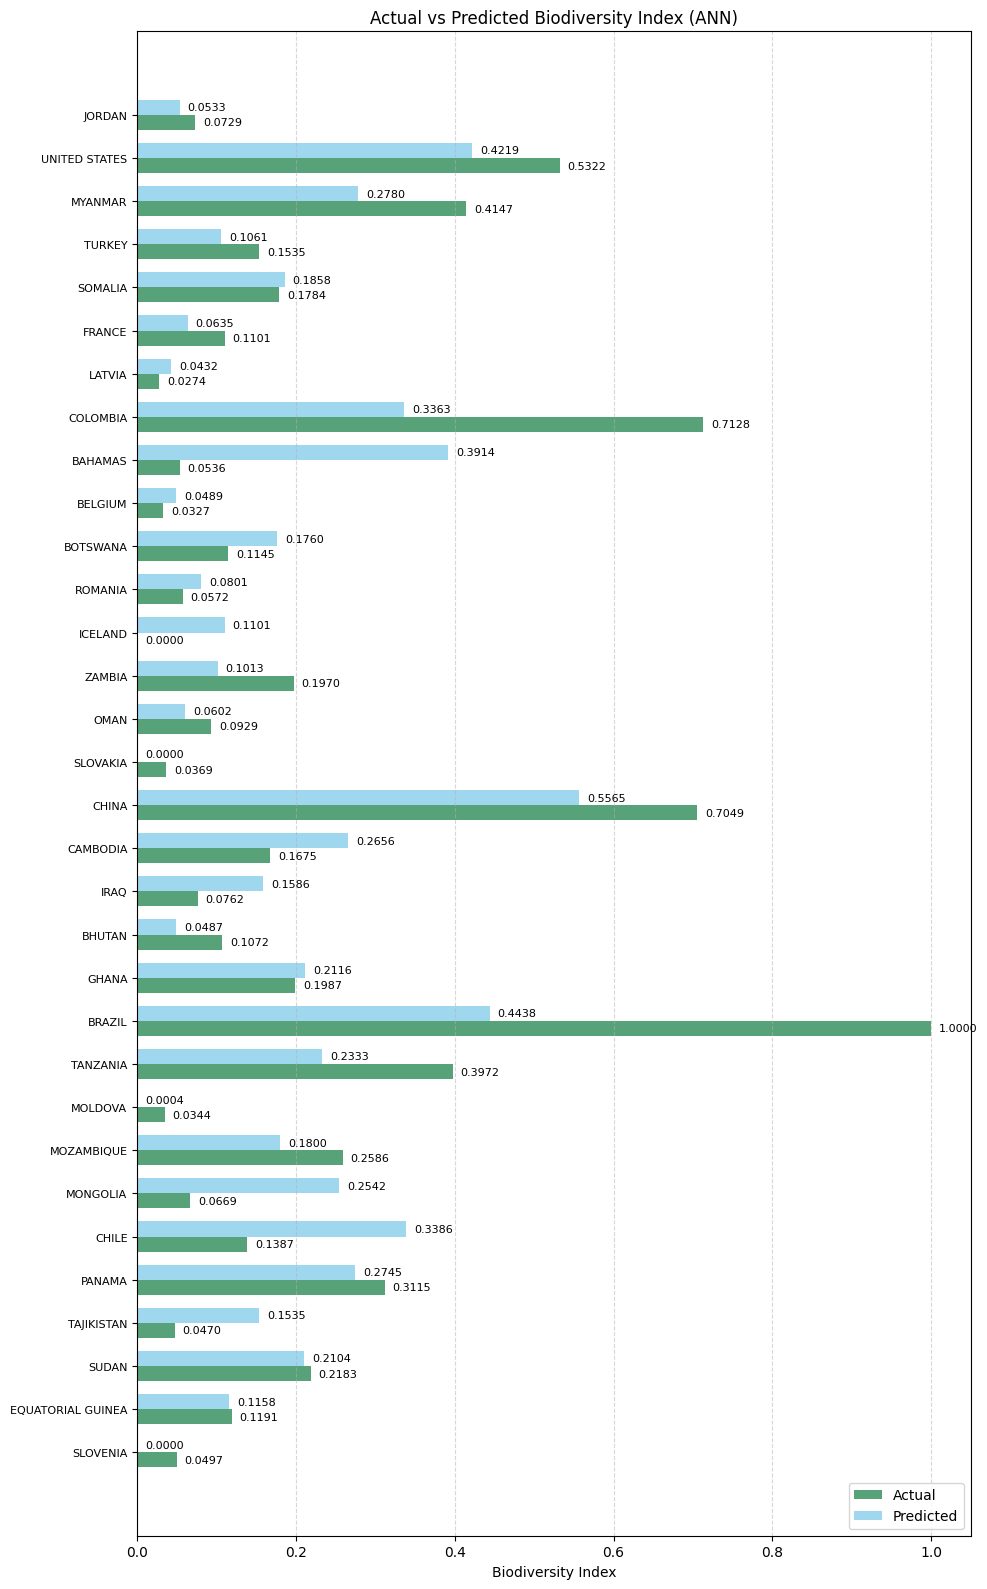

In [99]:
# Bar chart comparing actual vs predicted biodiversity values
x = np.arange(len(countries_test))
height = 0.35

plt.figure(figsize=(10, 16))
plt.barh(x - height/2, y_test, height, label='Actual', color='seagreen', alpha=0.8)
plt.barh(x + height/2, y_pred, height, label='Predicted', color='skyblue', alpha=0.8)

for i, v in enumerate(y_test):
    plt.text(v + 0.01, i - height/2, f"{v:.4f}", va='center', fontsize=8)
for i, v in enumerate(y_pred):
    plt.text(v + 0.01, i + height/2, f"{v:.4f}", va='center', fontsize=8)

plt.yticks(x, countries_test, fontsize=8)
plt.xlabel("Biodiversity Index")
plt.title("Actual vs Predicted Biodiversity Index (ANN)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


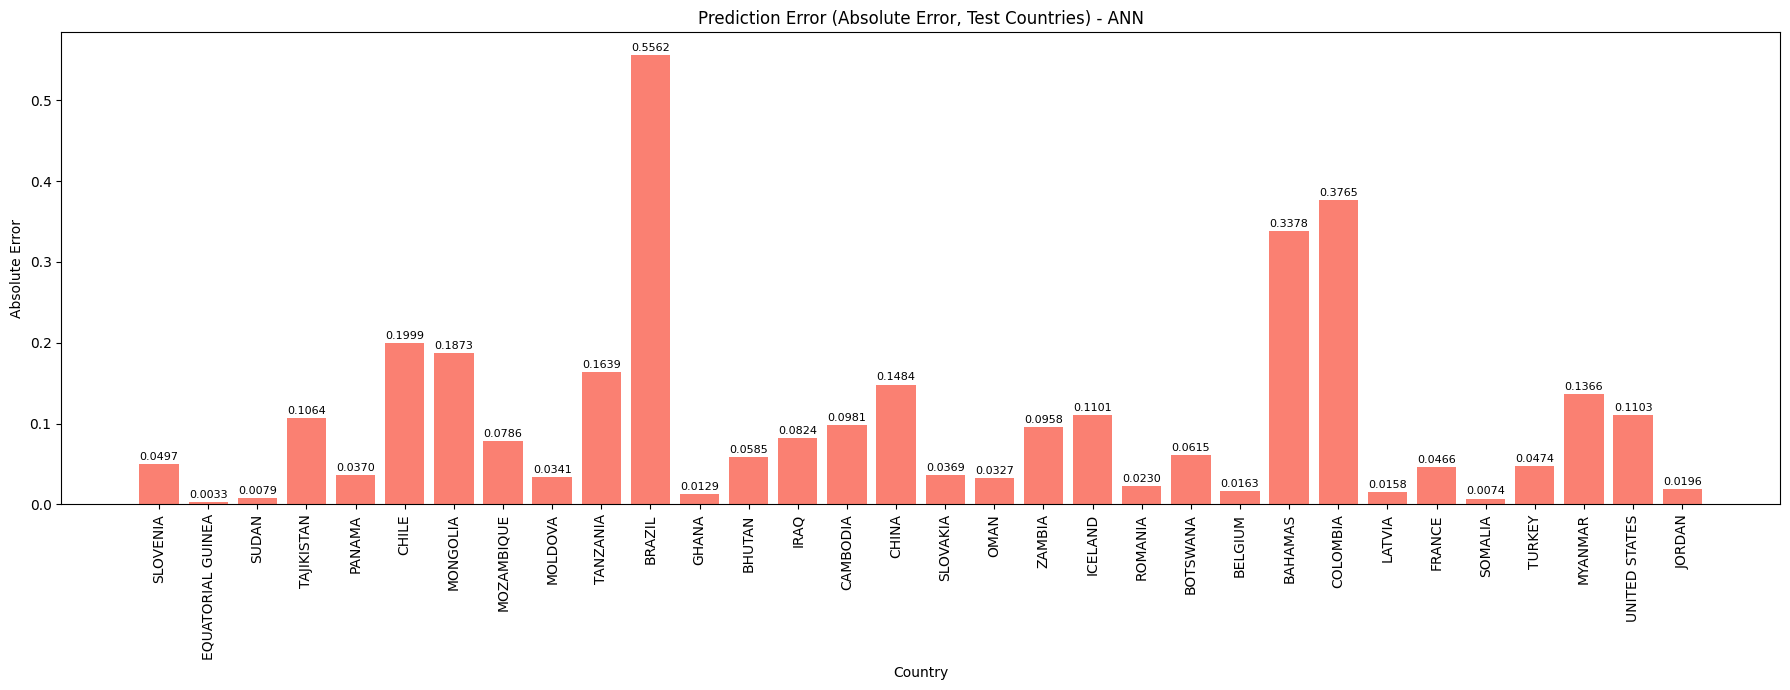

In [100]:
# Bar chart showing the absolute prediction error per country
error = np.abs(y_test - y_pred)

plt.figure(figsize=(18, 7))
plt.bar(countries_test, error, color="salmon")

for i, v in enumerate(error):
    plt.text(i, v + 0.005, f"{v:.4f}", color='black', ha='center', fontsize=8)

plt.xticks(rotation=90)
plt.ylabel("Absolute Error")
plt.xlabel("Country")
plt.title("Prediction Error (Absolute Error, Test Countries) - ANN")
plt.tight_layout()
plt.show()


C:\Users\ozgur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
C:\Users\ozgur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
C:\Users\ozgur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
C:\Users\ozgur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\

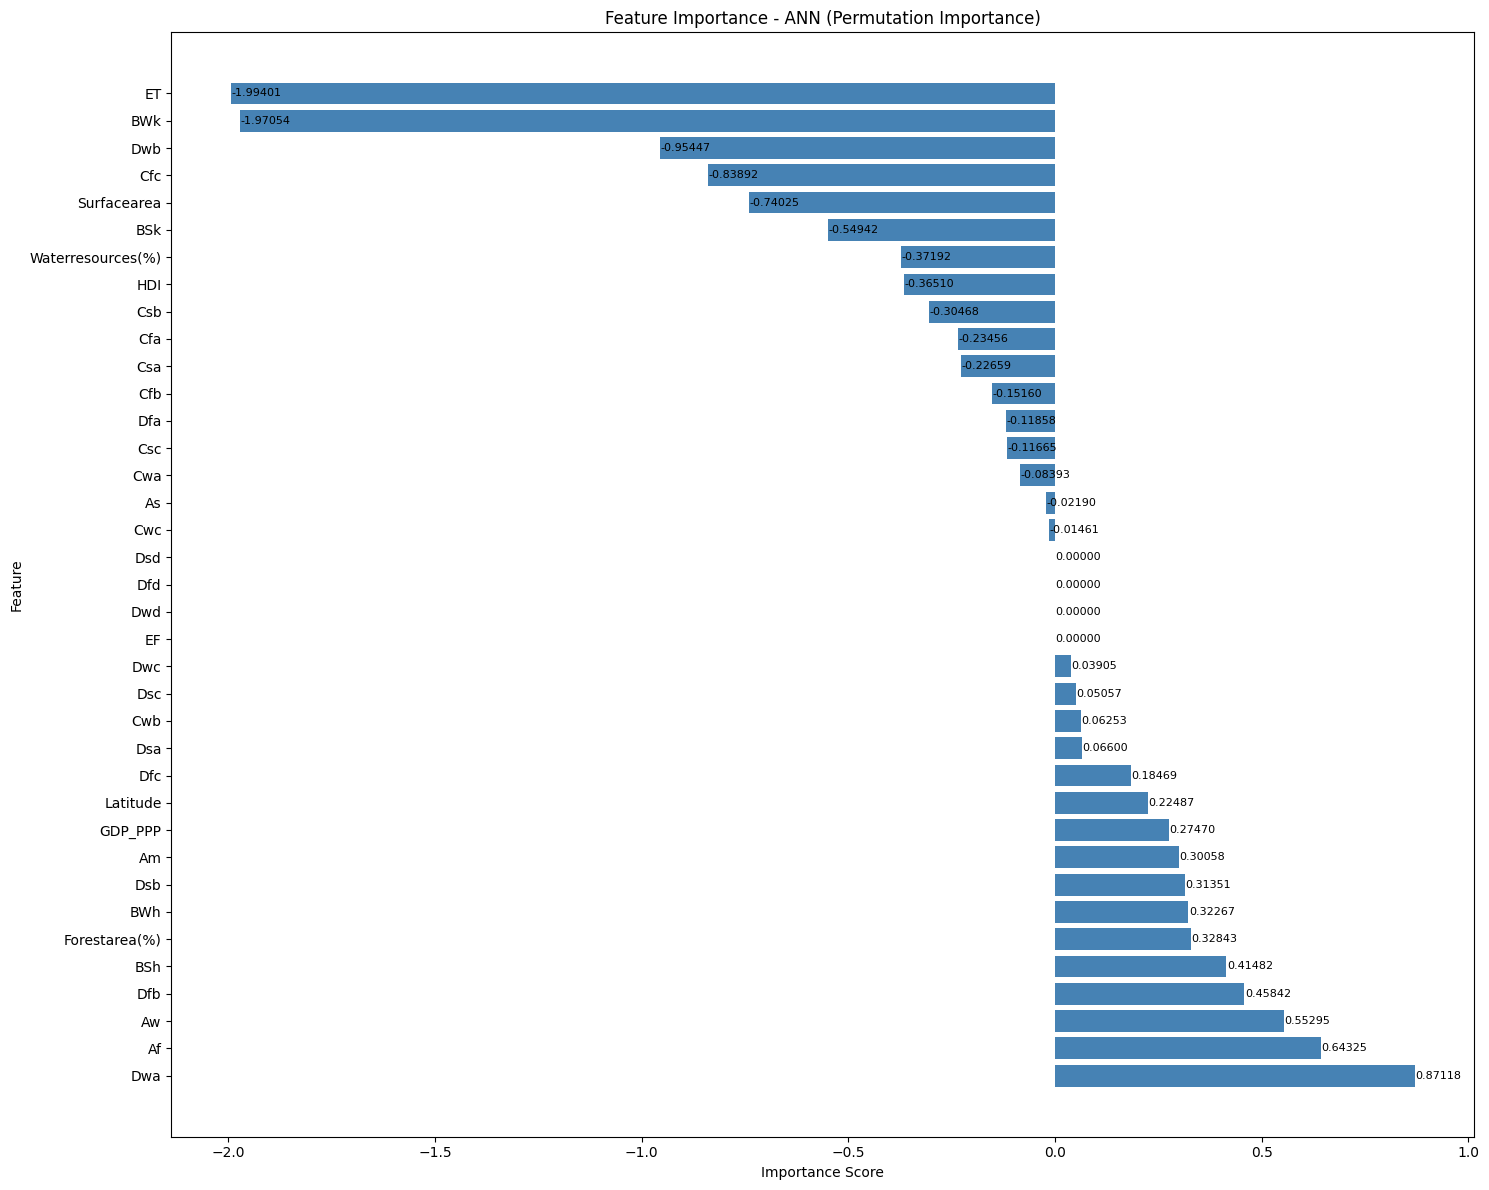

In [101]:
result = permutation_importance(ann_model,  X_test_scaled, y_test, scoring='r2', n_repeats=10, random_state=42)
importances = result.importances_mean
indices = np.argsort(importances)[::-1]
features_sorted = X.columns[indices]

plt.figure(figsize=(15, 12))
plt.barh(features_sorted, importances[indices], color="steelblue")
for i, v in enumerate(importances[indices]):
    plt.text(v + 0.001, i, f"{v:.5f}", color='black', va='center', fontsize=8)

plt.title("Feature Importance - ANN (Permutation Importance)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

ValueError: Wedge sizes 'x' must be non negative values

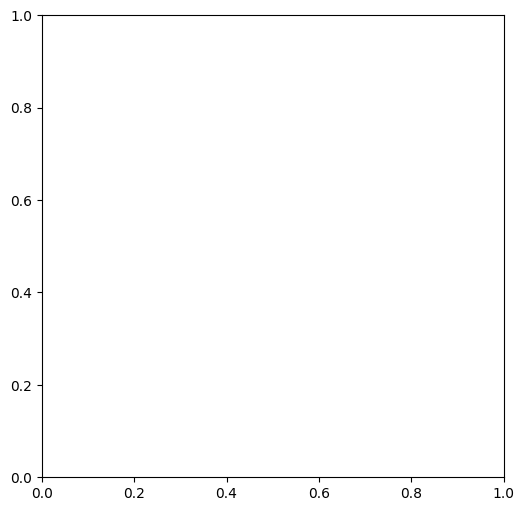

In [102]:
# Group features into categories and calculate summed importance for each
economy_features = ['GDP_PPP', 'HDI', 'Surfacearea']
natural_features = ['Latitude', 'Forestarea(%)', 'Waterresources(%)']
climate_features = [f for f in X.columns if f not in economy_features + natural_features]

category_scores = {
    'Economy': sum(importances[X.columns.get_loc(f)] for f in economy_features),
    'Natural Environment': sum(importances[X.columns.get_loc(f)] for f in natural_features),
    'Climate': sum(importances[X.columns.get_loc(f)] for f in climate_features),
}

df_grouped = pd.DataFrame.from_dict(category_scores, orient='index', columns=['Importance'])

# Plot pie chart
labels = df_grouped.index
sizes = df_grouped['Importance']
colors = ['#66c2a5', '#fc8d62', '#8da0cb']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title("Grouped Feature Importance by Category (ANN)")
plt.axis('equal')  # Ensures pie chart is circular
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'hidden_layer_sizes': [(32, 16), (16, 8), (24, 12)], # Testing shallow but varied architectures
    'alpha': [0.01, 0.05, 0.1],                         # Higher regularization to combat small data noise
    'activation': ['relu', 'tanh'],                     # Comparing Relu vs Tanh for pre-scaled [0,1] data
    'learning_rate_init': [0.001, 0.005]
}

In [ ]:
mlp = MLPRegressor(
    solver='adam',
    max_iter=3000,
    early_stopping=False,
    random_state=42
)

In [ ]:
# Using 5-fold cross-validation to ensure results are not lucky splits
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
best_ann_model = grid_search.best_estimator_

# Final Prediction
y_pred = best_ann_model.predict(X_test)
y_pred = np.clip(y_pred, 0, 1)

Best parameters found: {'activation': 'relu', 'alpha': 0.1, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.005}
